In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Pole powierzchni tacki: 221212.0
Wykryto monet: 12


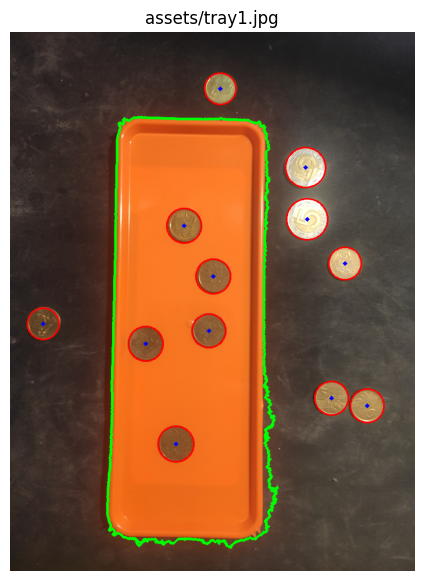

Pole powierzchni tacki: 190112.0
Wykryto monet: 12


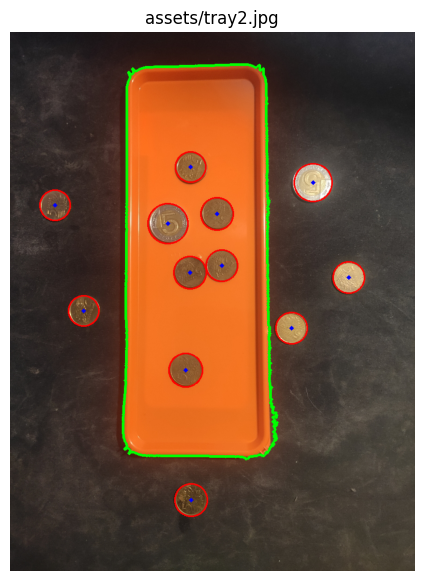

Pole powierzchni tacki: 160289.5
Wykryto monet: 12


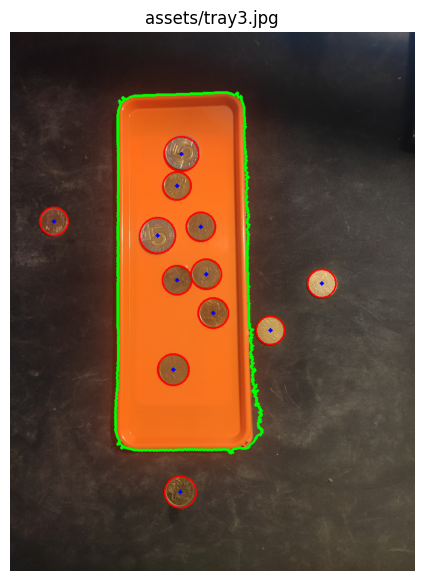

Pole powierzchni tacki: 167341.5
Wykryto monet: 12


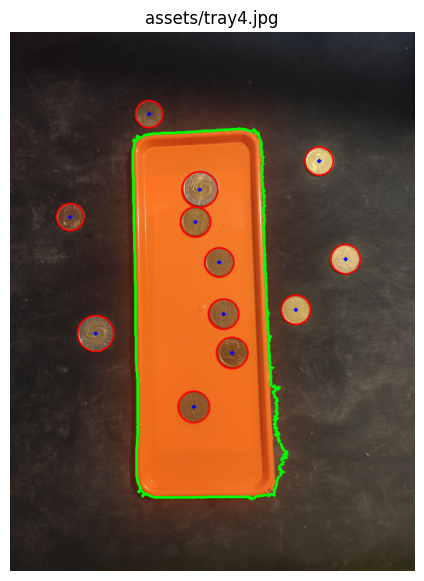

Pole powierzchni tacki: 181133.5
Wykryto monet: 12


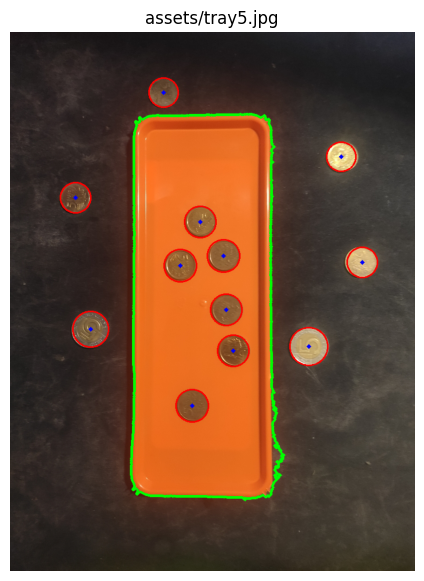

Pole powierzchni tacki: 174338.5
Wykryto monet: 12


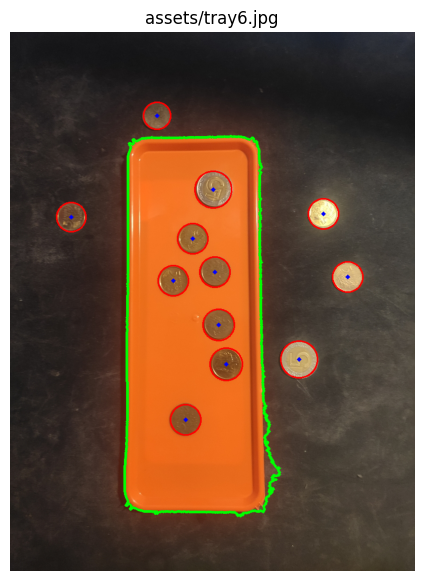

Pole powierzchni tacki: 192488.5
Wykryto monet: 12


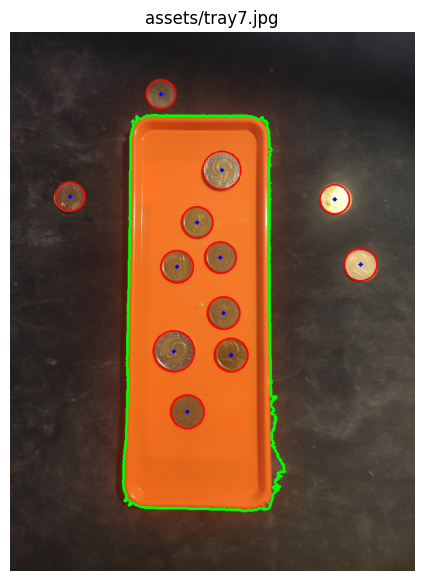

Pole powierzchni tacki: 199954.0
Wykryto monet: 12


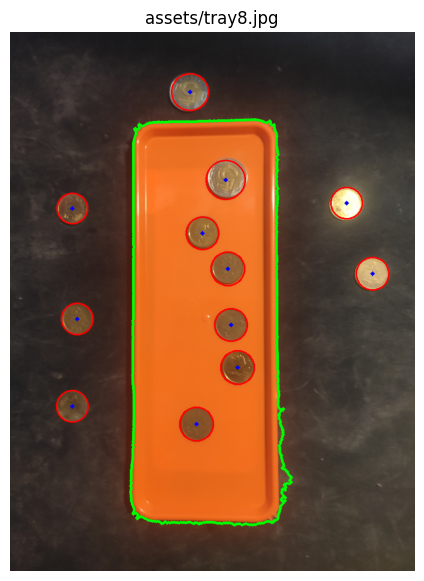

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def przetwarzaj_zdjecie(sciezka_do_zdjecia):
    obraz = cv2.imread(sciezka_do_zdjecia)
    if obraz is None:
        print(f"Błąd: Nie znaleziono pliku: {sciezka_do_zdjecia}")
        return
        
    Kopia_obrazu = obraz.copy()
    
    hsv = cv2.cvtColor(obraz, cv2.COLOR_BGR2HSV)
    
    maska_tacki = cv2.inRange(hsv, np.array([5, 100, 100]), np.array([25, 255, 255]))    

    kontury, _ = cv2.findContours(maska_tacki, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if kontury:
        kontur_tacki = max(kontury, key=cv2.contourArea)
        cv2.drawContours(Kopia_obrazu, [kontur_tacki], -1, (0, 255, 0), 3)
        pole_tacki = cv2.contourArea(kontur_tacki)
        print(f"Pole powierzchni tacki: {pole_tacki}")
    else:
        print("Nie wykryto tacki!")

    szary = cv2.cvtColor(obraz, cv2.COLOR_BGR2GRAY)
    
    rozmyty = cv2.medianBlur(szary, 5)

    okregi = cv2.HoughCircles(
        rozmyty, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
        param1=110, param2=47, minRadius=15, maxRadius=80
    )

    if okregi is not None:
        okregi = np.uint16(np.around(okregi))
        print(f"Wykryto monet: {len(okregi[0])}")
        
        for okrag in okregi[0, :]:
            x, y, promien = okrag[0], okrag[1], okrag[2]
            cv2.circle(Kopia_obrazu, (x, y), promien, (0, 0, 255), 2)
            cv2.circle(Kopia_obrazu, (x, y), 2, (255, 0, 0), 3)

    Kopia_RGB = cv2.cvtColor(Kopia_obrazu, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 7))
    plt.imshow(Kopia_RGB)
    plt.title(sciezka_do_zdjecia)
    plt.axis('off')
    plt.show()

przetwarzaj_zdjecie('assets/tray1.jpg')
przetwarzaj_zdjecie('assets/tray2.jpg')
przetwarzaj_zdjecie('assets/tray3.jpg')
przetwarzaj_zdjecie('assets/tray4.jpg')
przetwarzaj_zdjecie('assets/tray5.jpg')
przetwarzaj_zdjecie('assets/tray6.jpg')
przetwarzaj_zdjecie('assets/tray7.jpg')
przetwarzaj_zdjecie('assets/tray8.jpg')